In [54]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import sys
sys.path.append('../')

import superstats as sup
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats

import jax
print(jax.devices())

[CpuDevice(id=0)]


## Constants

In [55]:
NUM_STEPS = 800
NUM_SAMPLES = 1000
NUM_EPOCHS = 100
NUM_ITER_PER_EPOCH = 1000
BATCH_SIZE = 32

## Prior

In [60]:
joint_prior = sup.prior.JointPrior(
    v = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(
                sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
                delta=0
            ),
            sup.transition.Jump(
                proposal_prior=sup.prior.Prior(dist="logistic", loc=0, scale=1)
            )
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[20.0, 1.5]),
        bounds=(0.0, 8.0),
        initial_prior=sup.prior.Prior(dist="normal", loc=-1.0, scale=1.0),
    ),
    a = sup.transition.Mixture(
        transitions=[
            sup.transition.RandomWalk(
                sigma=sup.prior.Prior(dist="halfnormal", scale=0.1),
                delta=0
            ),
            sup.transition.Jump(
                proposal_prior=sup.prior.Prior(dist="logistic", loc=0, scale=1)
            )
        ],
        mixture_weights=sup.prior.Prior(dist="dirichlet", alpha=[40.0, 1.5]),
        bounds=(0.0, 6.0),
        initial_prior=sup.prior.Prior(dist="normal", loc=-0.5, scale=1.0),
    ),
    tau = sup.transition.RandomWalk(
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.01),
        delta=0,
        bounds=(0.0, 4.0),
        initial_prior=sup.prior.Prior(dist="normal", loc=-1.0, scale=1.0)
    ),
    bias = 0.5
)

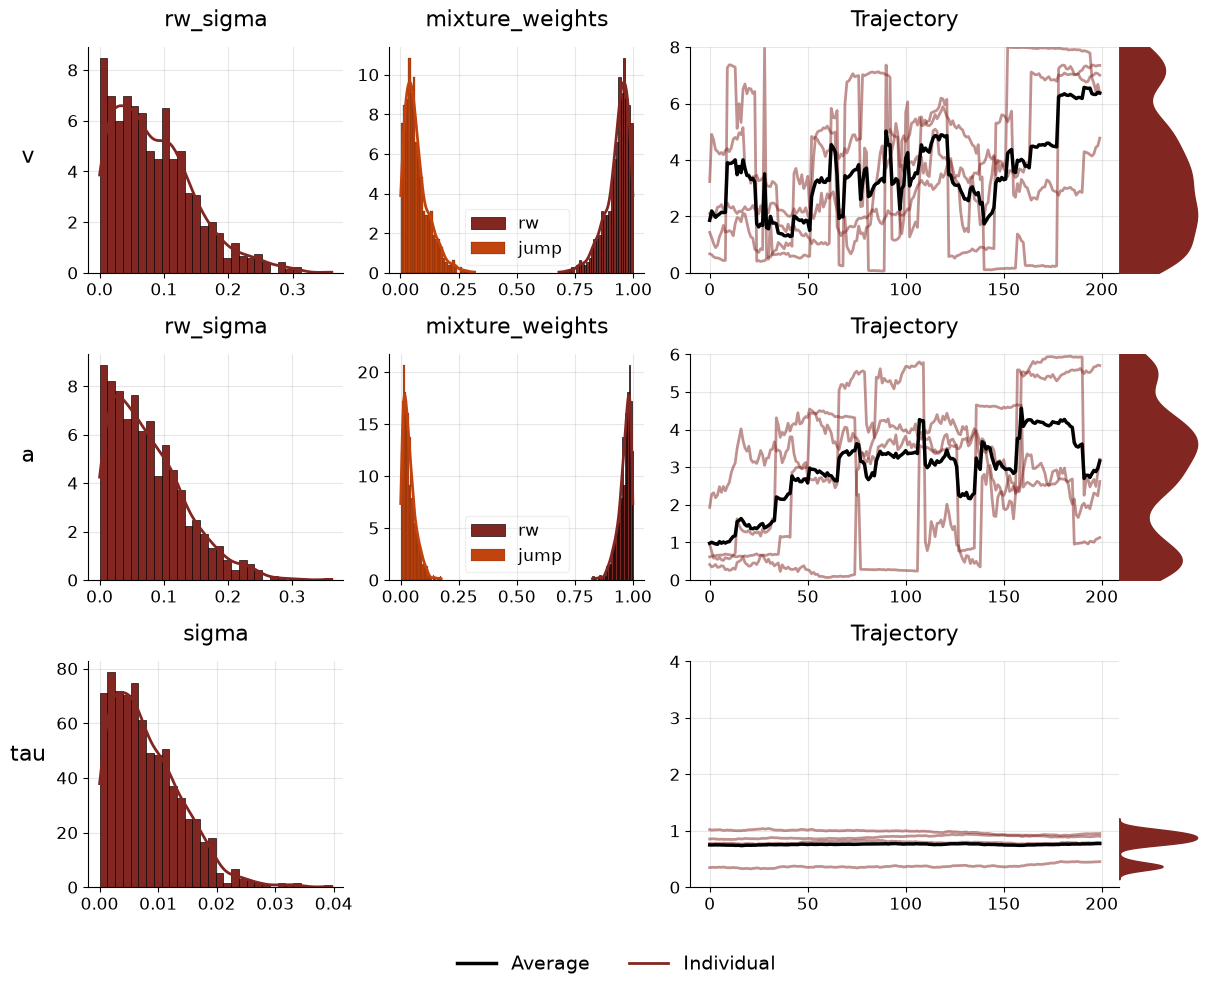

In [61]:
fig = joint_prior.plot_joint_prior(num_trajectories=4)

## Generative Model

In [62]:
ddm = sup.simulation.sample_ddm

generative_model = sup.simulation.GenerativeModel(
    prior=joint_prior,
    model=ddm,
)

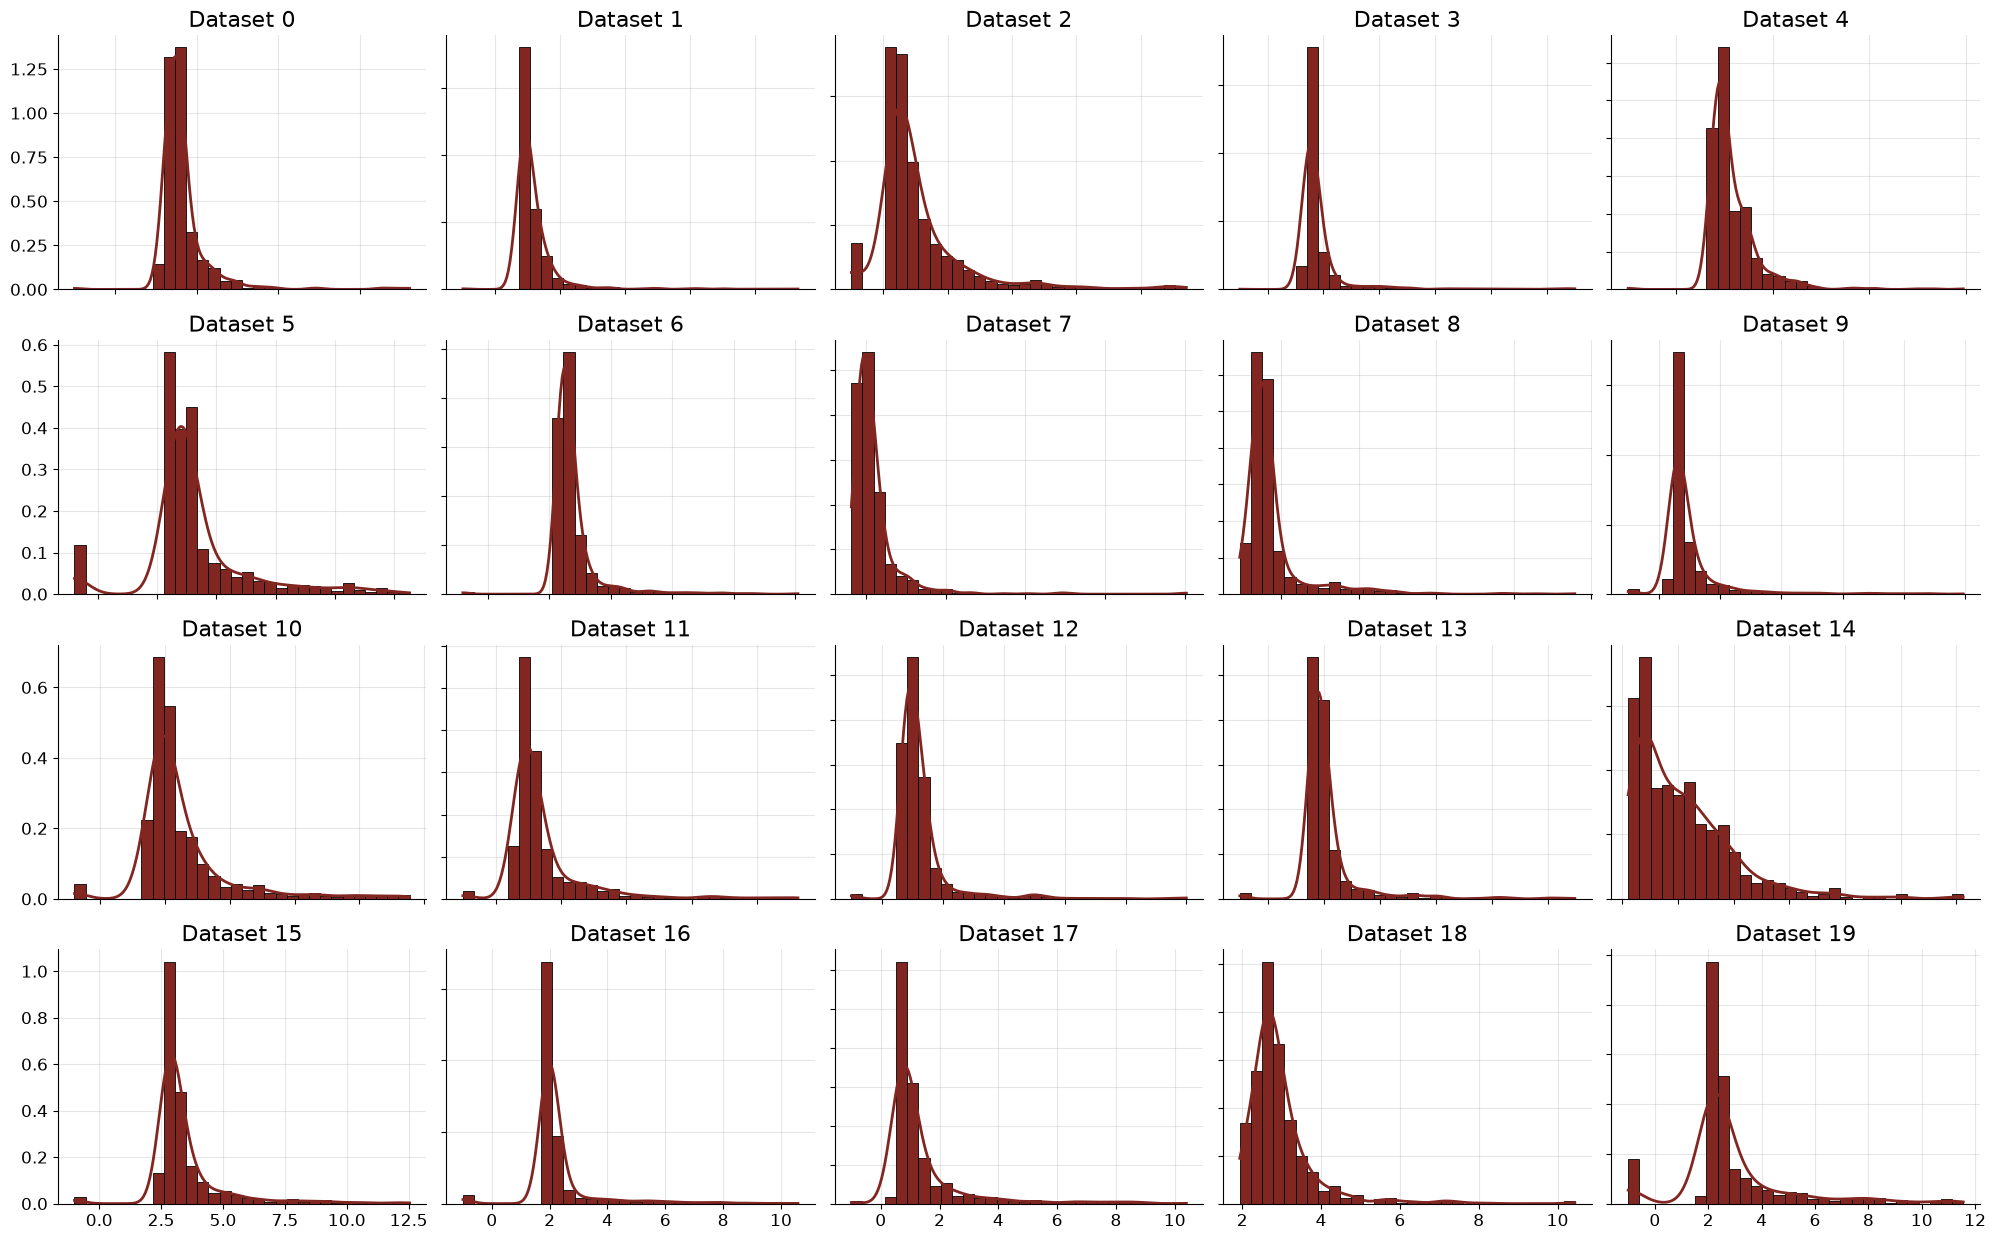

In [68]:
fig = generative_model.plot_push_forward(
    num_sim=20,
    num_steps=NUM_STEPS,
    data_dim=0,
    kind="dist",
    num_cols=5,
)

## Workflow

In [69]:
workflow = sup.workflow.Workflow(
    simulator=generative_model,
    checkpoint_filepath="data_application_01"
)

/var/folders/9q/trrmd4jn4bx40rltjz_fmx4h0000gp/T/ipykernel_91370/1391698141.py:1: UserWarning: restore_approximator=True but no model found at 'data_application_01'. Starting with no trained model.
  workflow = sup.workflow.Workflow(
/var/folders/9q/trrmd4jn4bx40rltjz_fmx4h0000gp/T/ipykernel_91370/1391698141.py:1: UserWarning: restore_history=True but no history found at 'data_application_01'. Starting with no history.
  workflow = sup.workflow.Workflow(


## Training

In [ ]:
history = workflow.fit_online(
    num_steps=NUM_STEPS,
    epochs=NUM_EPOCHS,
    num_batches_per_epoch=NUM_ITER_PER_EPOCH,
    batch_size=BATCH_SIZE
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
  20/1000 ━━━━━━━━━━━━━━━━━━━━ 12:22 757ms/step - loss: -0.0170

In [ ]:
fig = workflow.plot_history(workflow.history)

## Verification

In [ ]:
val_data = workflow.simulator.sample(
    batch_size=500,
    num_steps=NUM_STEPS
)

In [ ]:
samples = workflow.sample(
    data=val_data['data'],
    num_samples=NUM_SAMPLES,
    inference_batch_size=1
)

### Time-varying Parameters

In [ ]:
fig = workflow.validate_time_varying(val_data, samples)

### Time-invariant Parameters

In [ ]:
fig_recovery, fig_calibration = workflow.validate_time_invariant(
    val_data,
    samples
)

## Data Fitting